In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/clarra/dataset-all-split/dataset_with_split.csv


# M1 — IndoBERT Fine-tuned (Multilabel Wide Format)
## Hyperparameters:
| Param | Value |
|---|---|
| Learning rate | 2e-5 |
| Batch size | 16 |
| Max length | 128 |
| Epochs | 10 |
| Patience | 3 |
| Dropout | 0.3 |
| Optimizer | AdamW |
| Loss | Cross Entropy |

---
## Section 1: Setup & Imports

In [2]:
import os, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, classification_report

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')

PyTorch  : 2.10.0+cu128
CUDA     : True


In [3]:
# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


---
## Section 2: Configuration & Constants

In [4]:
# ── Centralized config ────────────────────────────────────────────────────────
CONFIG = {
    'model_name'    : 'indobenchmark/indobert-base-p1',
    'num_outputs'   : 4,      
    'dropout'       : 0.3,
    'max_length'    : 128,      
    'batch_size'    : 16,
    'learning_rate' : 2e-5,
    'weight_decay'  : 0.01,
    'epochs'        : 10,
    'patience'      : 3,
    'warmup_ratio'  : 0.1,
    'grad_clip'     : 1.0,
    'seed'          : SEED,
}

# ── Label definitions ─────────────────────────────────────────────────────────
ASPECTS  = ['PIGMENTATION', 'LONGEVITY', 'TEXTURE', 'HYDRATION', 'PRICE']
SENTIMENTS = ['no_aspect', 'negative', 'neutral', 'positive']  
SENT2ID  = {s: i for i, s in enumerate(SENTIMENTS)}
ID2SENT  = {i: s for s, i in SENT2ID.items()}


# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH          = '/kaggle/input/datasets/clarra/dataset-all-split/dataset_with_split.csv'
OUTPUT_DIR         = '/kaggle/working'
BEST_MODEL_PATH    = f'{OUTPUT_DIR}/m1-4cls_best.pt'
PREDICTIONS_PATH   = f'{OUTPUT_DIR}/m1-4cls_predictions.csv'
METRICS_PATH       = f'{OUTPUT_DIR}/m1-4cls_metrics.json'
LOSS_PLOT_PATH     = f'{OUTPUT_DIR}/m1-4cls_loss_convergence.png'
CM_PLOT_PATH       = f'{OUTPUT_DIR}/m1-4cls_confusion_matrix.png'
PERASPECT_PLOT_PATH= f'{OUTPUT_DIR}/m1-4cls_per_aspect_results.png'

assert os.path.exists(DATA_PATH), f'Dataset not found: {DATA_PATH}'
print('Config loaded.')
for k, v in CONFIG.items():
    print(f'  {k:<16} {v}')

Config loaded.
  model_name       indobenchmark/indobert-base-p1
  num_outputs      4
  dropout          0.3
  max_length       128
  batch_size       16
  learning_rate    2e-05
  weight_decay     0.01
  epochs           10
  patience         3
  warmup_ratio     0.1
  grad_clip        1.0
  seed             42


---
## Section 3: Load Data & EDA

In [5]:
df = pd.read_csv(DATA_PATH)
print(f'Total rows : {len(df)}')
print(f'Columns    : {df.columns.tolist()}')
print()
print('Split distribution:')
print(df['split'].value_counts().to_string())
display(df.head(3))

Total rows : 1098
Columns    : ['review_id', 'review_text', 'product_name', 'product_brand', 'PIGMENTATION', 'LONGEVITY', 'TEXTURE', 'HYDRATION', 'PRICE', 'is_synthetic', 'source_fase', 'method', 'split']

Split distribution:
split
train    998
val       50
test      50


,review_id,review_text,product_name,product_brand,PIGMENTATION,LONGEVITY,TEXTURE,HYDRATION,PRICE,is_synthetic,source_fase,method,split
0,388,"Aku kira bakalan aroma strawberrynya kuat, ter...",24H Melt-In Moisture,Nivea,no_aspect,no_aspect,no_aspect,positive,no_aspect,False,NaN,NaN,train
1,334,Beli produk ini tuh awalnya karena IKON hahaha...,24H Melt-In Moisture,Nivea,positive,no_aspect,no_aspect,positive,no_aspect,False,NaN,NaN,train
2,142,My favorit lip balm!! enggak bikin bibir kerin...,24H Melt-In Moisture,Nivea,neutral,no_aspect,positive,positive,no_aspect,False,NaN,NaN,train


In [6]:
# ── Label distribution per aspect ────────────────────────────────────────────
print('Label distribution per aspect (train set):')
train_df = df[df['split'] == 'train']
print(f'{"Aspect":<14} {"positive":>9} {"negative":>9} {"neutral":>9} {"no_aspect":>10} {"imb_ratio":>10}')
print('-' * 65)
for asp in ASPECTS:
    counts  = train_df[asp].value_counts()
    pos     = counts.get('positive',  0)
    neg     = counts.get('negative',  0)
    neu     = counts.get('neutral',   0)
    noa     = counts.get('no_aspect', 0)
    sents   = [c for c in [pos, neg, neu] if c > 0]
    ratio   = max(sents) / min(sents) if sents else 0
    print(f'{asp:<14} {pos:>9} {neg:>9} {neu:>9} {noa:>10} {ratio:>9.1f}:1')

Label distribution per aspect (train set):
Aspect          positive  negative   neutral  no_aspect  imb_ratio
-----------------------------------------------------------------
PIGMENTATION         377        98       172        351       3.8:1
LONGEVITY             93       193        40        672       4.8:1
TEXTURE              272       114        41        571       6.6:1
HYDRATION            584       176        85        153       6.9:1
PRICE                252        20        11        715      22.9:1


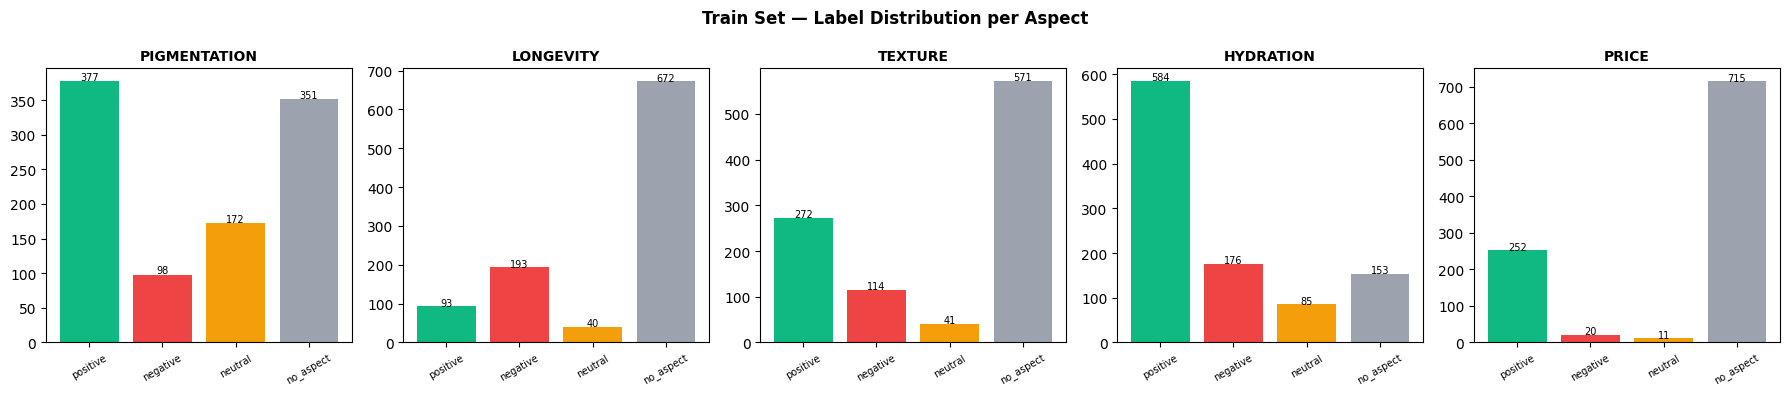

In [7]:
# ── Visualize label distribution ─────────────────────────────────────────────
SENT_COLORS = {'negative': '#ef4444', 'neutral': '#f59e0b',
               'positive': '#10b981', 'no_aspect': '#9ca3af'}

fig, axes = plt.subplots(1, len(ASPECTS), figsize=(18, 4), sharey=False)
for ax, asp in zip(axes, ASPECTS):
    counts = train_df[asp].value_counts().reindex(
        ['positive', 'negative', 'neutral', 'no_aspect'], fill_value=0
    )
    bars = ax.bar(counts.index, counts.values,
                  color=[SENT_COLORS[l] for l in counts.index])
    ax.set_title(asp, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, str(v),
                ha='center', fontsize=7)
plt.suptitle('Train Set — Label Distribution per Aspect', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 4: Tokenizer & Dataset

In [8]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print(f'Tokenizer : {CONFIG["model_name"]}')
print(f'Vocab size: {tokenizer.vocab_size:,}')

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer : indobenchmark/indobert-base-p1
Vocab size: 30,521


In [9]:
class ABSADataset(Dataset):

    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 128):
        self.df         = df.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        enc = self.tokenizer(
            str(row['review_text']),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )

        labels = torch.zeros(5, dtype=torch.long)

        for asp_idx, asp in enumerate(ASPECTS):
            val = row[asp]
            labels[asp_idx] = SENT2ID[val] 

        return {
            'input_ids'     : enc['input_ids'].squeeze(0),       
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': enc['token_type_ids'].squeeze(0),
            'labels'        : labels,                                                       
            'review_id': str(row['review_id']),
        }

In [10]:
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'  ].reset_index(drop=True)
test_df  = df[df['split'] == 'test' ].reset_index(drop=True)

train_ds = ABSADataset(train_df, tokenizer, CONFIG['max_length'])
val_ds   = ABSADataset(val_df,   tokenizer, CONFIG['max_length'])
test_ds  = ABSADataset(test_df,  tokenizer, CONFIG['max_length'])

print(f'Train : {len(train_ds)} reviews')
print(f'Val   : {len(val_ds)} reviews')
print(f'Test  : {len(test_ds)} reviews')

# Sanity check one sample
s = train_ds[0]
print(f'\nSample 0:')
print(f'  input_ids shape : {s["input_ids"].shape}')
print(f'  labels          : {s["labels"]}')
print(f'  labels : {[(ASPECTS[i], SENTIMENTS[s["labels"][i].item()]) for i in range(5)]}')

Train : 998 reviews
Val   : 50 reviews
Test  : 50 reviews

Sample 0:
  input_ids shape : torch.Size([128])
  labels          : tensor([0, 0, 0, 3, 0])
  labels : [('PIGMENTATION', 'no_aspect'), ('LONGEVITY', 'no_aspect'), ('TEXTURE', 'no_aspect'), ('HYDRATION', 'positive'), ('PRICE', 'no_aspect')]


---
## Section 5: DataLoader

In [11]:
def collate_fn(batch):
    return {
        'input_ids'     : torch.stack([b['input_ids']      for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'token_type_ids': torch.stack([b['token_type_ids'] for b in batch]),
        'labels'        : torch.stack([b['labels']         for b in batch]),
        'review_id'     : [b['review_id'] for b in batch],
    }

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print(f'Test  batches: {len(test_loader)}')

# Verify batch shapes
b = next(iter(train_loader))
print(f'\nBatch shapes:')
for k in ['input_ids', 'attention_mask', 'token_type_ids', 'labels']:
    print(f'  {k:<16}: {b[k].shape}  dtype={b[k].dtype}')

Train batches: 63
Val   batches: 4
Test  batches: 4

Batch shapes:
  input_ids       : torch.Size([16, 128])  dtype=torch.int64
  attention_mask  : torch.Size([16, 128])  dtype=torch.int64
  token_type_ids  : torch.Size([16, 128])  dtype=torch.int64
  labels          : torch.Size([16, 5])  dtype=torch.int64


---
## Section 6: Model Definition

In [12]:
class M1_IndoBERT(nn.Module):
    def __init__(self, model_name: str, num_outputs: int = 4, dropout: float = 0.3):
        super().__init__()
        self.bert       = AutoModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, len(ASPECTS) * 4)  # kurung tutup 1x
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids, attention_mask, token_type_ids):
        out = self.bert(input_ids=input_ids,          
                        attention_mask=attention_mask,
                        token_type_ids=token_type_ids)
        cls = self.dropout(out.last_hidden_state[:, 0, :])  
        out = self.classifier(cls)                          
        return out.view(-1, 5, 4)                            

In [13]:
model = M1_IndoBERT(
    model_name  = CONFIG['model_name'],
    num_outputs = CONFIG['num_outputs'],
    dropout     = CONFIG['dropout'],
).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}')

# Forward pass sanity check
model.eval()
with torch.no_grad():
    sample = next(iter(train_loader))
    logits = model(sample['input_ids'].to(device),
                   sample['attention_mask'].to(device),
                   sample['token_type_ids'].to(device))
    print(f'Output shape    : {logits.shape}  (expected: [{CONFIG["batch_size"]}, 15])')
    print(f'Any NaN         : {torch.isnan(logits).any().item()}')

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Total params    : 124,456,724
Trainable params: 124,456,724
Output shape    : torch.Size([16, 5, 4])  (expected: [16, 15])
Any NaN         : False


---
## Section 7: Loss Function, Optimizer & Scheduler

In [14]:
def ce_loss(logits, labels):
    """
    CrossEntropyLoss untuk output (B, 5, 4).
    logits : (B, 5, 4) raw model output
    labels : (B, 5)    integer class index (0=no_aspect, 1=neg, 2=neu, 3=pos)
    """
    B = logits.size(0)
    return F.cross_entropy(
        logits.view(B * 5, 4),
        labels.view(B * 5),
        reduction='mean'
    )

In [15]:
# ── Optimizer: separate weight decay from bias/LayerNorm ─────────────────────
no_decay = ['bias', 'LayerNorm.weight']
optimizer_params = [
    {'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
     'weight_decay': CONFIG['weight_decay']},
    {'params': [p for n, p in model.named_parameters() if     any(nd in n for nd in no_decay)],
     'weight_decay': 0.0},
]
optimizer = torch.optim.AdamW(optimizer_params, lr=CONFIG['learning_rate'])

total_steps  = len(train_loader) * CONFIG['epochs']
warmup_steps = int(CONFIG['warmup_ratio'] * total_steps)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps,
)

print(f'Optimizer    : AdamW  lr={CONFIG["learning_rate"]}  wd={CONFIG["weight_decay"]}')
print(f'Total steps  : {total_steps}')
print(f'Warmup steps : {warmup_steps}')
print(f'Loss         : CrossEntropyLoss (4-class, no masking)')

Optimizer    : AdamW  lr=2e-05  wd=0.01
Total steps  : 630
Warmup steps : 63
Loss         : CrossEntropyLoss (4-class, no masking)


---
## Section 8: Metric Helpers

In [16]:
def preds_from_logits(logits: torch.Tensor) -> np.ndarray:
    return torch.argmax(logits, dim=-1).cpu().numpy()

def labels_from_tensor(labels: torch.Tensor) -> np.ndarray:
    return labels.cpu().numpy()

def compute_metrics(all_true: np.ndarray, all_pred: np.ndarray):
    t, p = all_true.flatten(), all_pred.flatten()
    return {
        'macro_f1'  : f1_score(t, p, average='macro', zero_division=0),
        'macro_prec': precision_score(t, p, average='macro', zero_division=0),
        'macro_rec' : recall_score(t, p, average='macro', zero_division=0),
        'accuracy'  : accuracy_score(t, p),
    }

def compute_per_aspect_metrics(all_true: np.ndarray, all_pred: np.ndarray):
    results = []
    for i, asp in enumerate(ASPECTS):
        t, p = all_true[:, i], all_pred[:, i]
        n    = len(t)
        f1   = f1_score(t, p, average='macro', zero_division=0)
        prec = precision_score(t, p, average='macro', zero_division=0)
        rec  = recall_score(t, p, average='macro', zero_division=0)
        acc  = accuracy_score(t, p)
        results.append({'aspect': asp, 'f1': f1, 'precision': prec,
                        'recall': rec, 'accuracy': acc, 'n_active': n})
    return results

print('Metric helpers defined.')

Metric helpers defined.


---
## Section 9: Training & Validation Loop

In [17]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    all_true, all_pred = [], []

    for batch in tqdm(loader, desc='Train', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, token_type_ids)  # (B, 5, 4)
        loss   = ce_loss(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_true.append(labels_from_tensor(labels.cpu()))
        all_pred.append(preds_from_logits(logits.detach().cpu()))

    all_true = np.vstack(all_true)
    all_pred = np.vstack(all_pred)
    return total_loss / len(loader), compute_metrics(all_true, all_pred)


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0
    all_true, all_pred = [], []

    for batch in tqdm(loader, desc='Eval ', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)

        logits     = model(input_ids, attention_mask, token_type_ids)
        total_loss += ce_loss(logits, labels).item()
        all_true.append(labels_from_tensor(labels.cpu()))
        all_pred.append(preds_from_logits(logits.cpu()))

    all_true = np.vstack(all_true)
    all_pred = np.vstack(all_pred)
    return total_loss / len(loader), compute_metrics(all_true, all_pred), all_true, all_pred

print('Train/eval functions defined.')

Train/eval functions defined.


In [18]:
history = {'train_loss': [], 'val_loss': [],
           'train_f1'  : [], 'val_f1'  : []}

best_val_f1      = 0.0
best_epoch       = 0
patience_counter = 0

print('=== Training M1 — IndoBERT Multilabel ===')
for epoch in range(CONFIG['epochs']):
    t0 = time.time()

    train_loss, train_m = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss,   val_m, _, _ = eval_epoch(model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['val_loss'  ].append(val_loss)
    history['train_f1'  ].append(train_m['macro_f1'])
    history['val_f1'    ].append(val_m['macro_f1'])

    elapsed = time.time() - t0
    print(f"Ep {epoch+1:02d}/{CONFIG['epochs']} "
          f"| TrLoss {train_loss:.4f}  ValLoss {val_loss:.4f} "
          f"| TrF1 {train_m['macro_f1']:.4f}  ValF1 {val_m['macro_f1']:.4f} "
          f"| {elapsed:.1f}s")

    if val_m['macro_f1'] > best_val_f1:
        best_val_f1 = val_m['macro_f1']
        best_epoch  = epoch + 1
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'  ⭐ Best model saved (ValF1={best_val_f1:.4f})')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['patience']:
            print(f'  🛑 Early stopping at epoch {epoch+1}')
            break

print(f'\nDone. Best epoch={best_epoch}, Best ValF1={best_val_f1:.4f}')

=== Training M1 — IndoBERT Multilabel ===


Train:   0%|          | 0/63 [00:00<?, ?it/s]

Eval :   0%|          | 0/4 [00:00<?, ?it/s]

Ep 01/10 | TrLoss 1.4203  ValLoss 1.1599 | TrF1 0.3308  ValF1 0.3487 | 22.0s
  ⭐ Best model saved (ValF1=0.3487)


Train:   0%|          | 0/63 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79e5e2e25da0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79e5e2e25da0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Ep 09/10 | TrLoss 0.2872  ValLoss 0.9017 | TrF1 0.8647  ValF1 0.6222 | 26.1s
  ⭐ Best model saved (ValF1=0.6222)


Train:   0%|          | 0/63 [00:00<?, ?it/s]

Eval :   0%|          | 0/4 [00:00<?, ?it/s]

Ep 10/10 | TrLoss 0.2440  ValLoss 0.9050 | TrF1 0.8942  ValF1 0.5982 | 25.0s

Done. Best epoch=9, Best ValF1=0.6222


---
## Section 10: Loss Convergence Plot

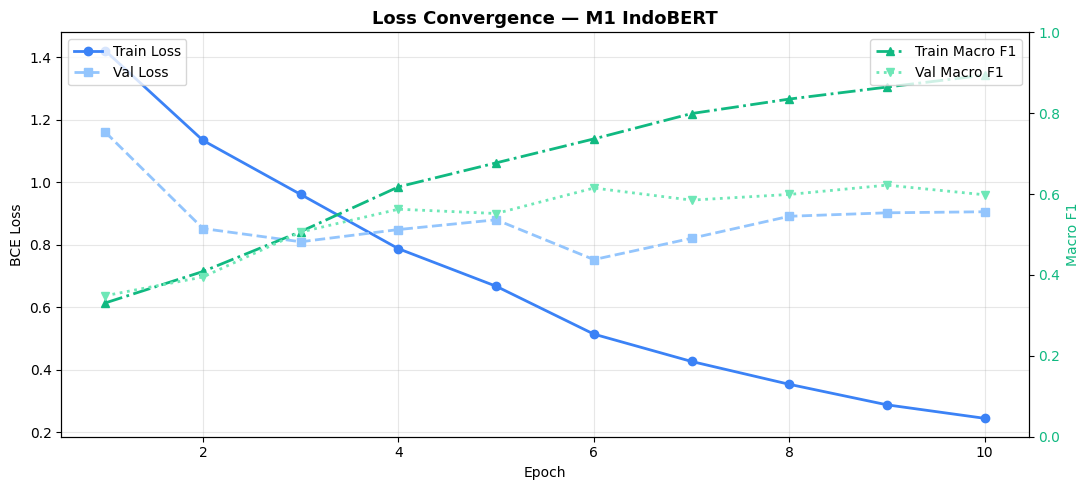

Saved: /kaggle/working/m1-4cls_loss_convergence.png


In [19]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(epochs_range, history['train_loss'], 'o-',  color='#3b82f6', label='Train Loss', lw=2)
ax1.plot(epochs_range, history['val_loss'],   's--', color='#93c5fd', label='Val Loss',   lw=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss'); ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_range, history['train_f1'], '^-.',  color='#10b981', label='Train Macro F1', lw=2)
ax2.plot(epochs_range, history['val_f1'],   'v:',   color='#6ee7b7', label='Val Macro F1',   lw=2)
ax2.set_ylabel('Macro F1', color='#10b981')
ax2.tick_params(axis='y', labelcolor='#10b981')
ax2.set_ylim([0, 1]); ax2.legend(loc='upper right')

plt.title('Loss Convergence — M1 IndoBERT', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(LOSS_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {LOSS_PLOT_PATH}')

---
## Section 11: Evaluasi Test Set

In [20]:
# Load best checkpoint
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.to(device)
print(f'Loaded best model from epoch {best_epoch}')

test_loss, test_m, test_true, test_pred = eval_epoch(model, test_loader, device)

print('\n' + '='*65)
print('TEST SET RESULTS — M1 IndoBERT (Proposal Section 2.2.4)')
print('='*65)
print(f'Test BCE Loss          : {test_loss:.4f}')
print(f'Accuracy  (Pers. 2.15) : {test_m["accuracy"]:.4f}')
print(f'Macro Precision        : {test_m["macro_prec"]:.4f}')
print(f'Macro Recall           : {test_m["macro_rec"]:.4f}')
print(f'Macro F1   (Pers. 2.14): {test_m["macro_f1"]:.4f}')

Loaded best model from epoch 9


Eval :   0%|          | 0/4 [00:00<?, ?it/s]


TEST SET RESULTS — M1 IndoBERT (Proposal Section 2.2.4)
Test BCE Loss          : 0.7351
Accuracy  (Pers. 2.15) : 0.6760
Macro Precision        : 0.5436
Macro Recall           : 0.5158
Macro F1   (Pers. 2.14): 0.5199


In [21]:
per_asp = compute_per_aspect_metrics(test_true, test_pred)

print('\nPer-Aspect Results (4-class: no_aspect, negative, neutral, positive):')
print(f'{"Aspect":<14} {"F1":>8} {"Prec":>8} {"Rec":>8} {"Acc":>8} {"N":>5}')
print('-'*55)
for r in per_asp:
    print(f'{r["aspect"]:<14} {r["f1"]:>8.4f} {r["precision"]:>8.4f} '
          f'{r["recall"]:>8.4f} {r["accuracy"]:>8.4f} {r["n_active"]:>5}')
avg_f1 = float(np.mean([r['f1'] for r in per_asp]))
print('-'*55)
print(f'{"MACRO AVG":<14} {avg_f1:>8.4f}')


Per-Aspect Results (4-class: no_aspect, negative, neutral, positive):
Aspect               F1     Prec      Rec      Acc     N
-------------------------------------------------------
PIGMENTATION     0.5074   0.5045   0.6138   0.5600    50
LONGEVITY        0.4161   0.4630   0.3958   0.7400    50
TEXTURE          0.3364   0.3385   0.3553   0.5400    50
HYDRATION        0.4614   0.4678   0.4639   0.6600    50
PRICE            0.8252   0.8252   0.8252   0.8800    50
-------------------------------------------------------
MACRO AVG        0.5093


In [22]:
flat_true = test_true.flatten()
flat_pred = test_pred.flatten()

print('Global Classification Report (4-class):')
print(classification_report(flat_true, flat_pred,
      target_names=SENTIMENTS, digits=4, zero_division=0))

Global Classification Report (4-class):
              precision    recall  f1-score   support

   no_aspect     0.7634    0.7812    0.7722       128
    negative     0.4194    0.4643    0.4407        28
     neutral     0.3333    0.1429    0.2000        14
    positive     0.6585    0.6750    0.6667        80

    accuracy                         0.6760       250
   macro avg     0.5436    0.5158    0.5199       250
weighted avg     0.6672    0.6760    0.6693       250



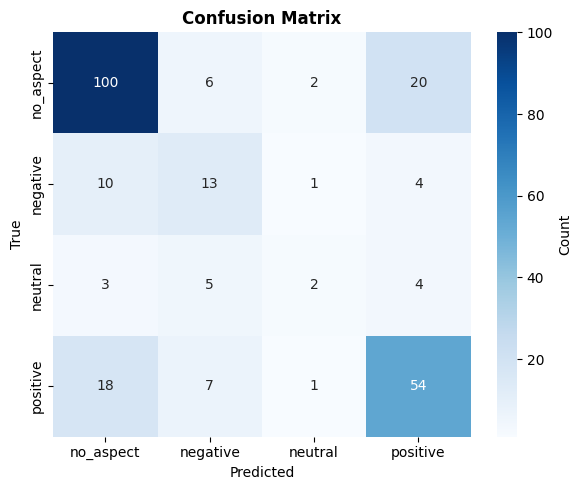

Saved: /kaggle/working/m1-4cls_confusion_matrix.png


In [23]:
# ── Confusion matrix (global active slots) ───────────────────────────────────
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(flat_true, flat_pred, labels=[0, 1, 2, 3])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SENTIMENTS, yticklabels=SENTIMENTS,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig(CM_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {CM_PLOT_PATH}')

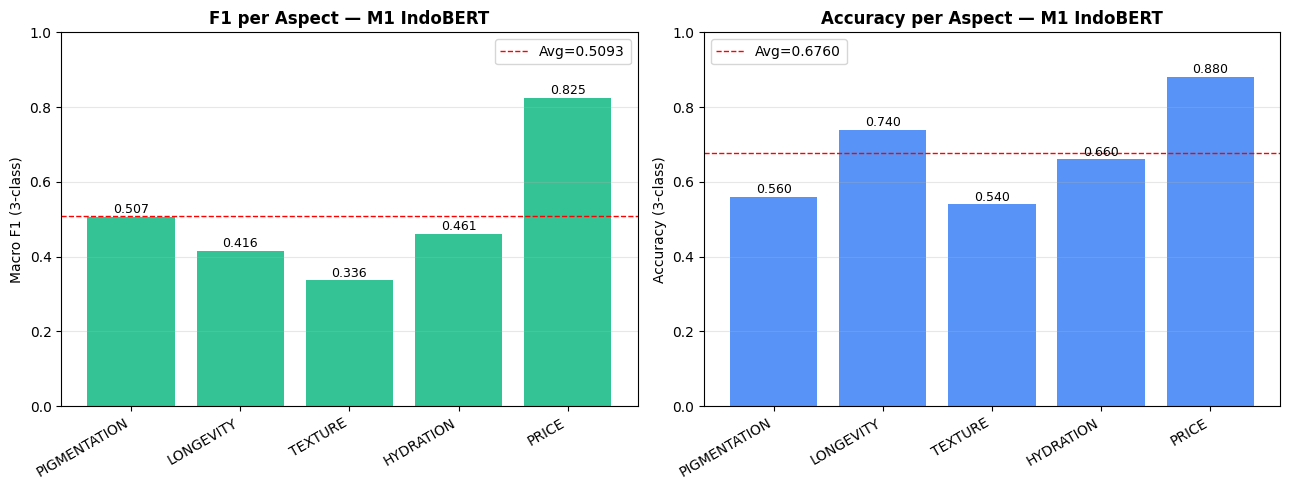

Saved: /kaggle/working/m1-4cls_per_aspect_results.png


In [24]:
# ── Per-aspect F1 bar chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(ASPECTS))

f1_vals  = [r['f1']       for r in per_asp]
acc_vals = [r['accuracy'] for r in per_asp]

for ax, vals, ylabel, color in zip(
        axes,
        [f1_vals, acc_vals],
        ['Macro F1 (3-class)', 'Accuracy (3-class)'],
        ['#10b981', '#3b82f6']):
    bars = ax.bar(x, vals, color=color, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(ASPECTS, rotation=30, ha='right')
    ax.set_ylabel(ylabel); ax.set_ylim([0, 1])
    ax.axhline(np.mean(vals), color='red', linestyle='--', linewidth=1,
               label=f'Avg={np.mean(vals):.4f}')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', fontsize=9)

axes[0].set_title('F1 per Aspect — M1 IndoBERT', fontweight='bold')
axes[1].set_title('Accuracy per Aspect — M1 IndoBERT', fontweight='bold')
plt.tight_layout()
plt.savefig(PERASPECT_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PERASPECT_PLOT_PATH}')

---
## Section 12: Hamming Loss (Proposal Persamaan 2.16)

In [25]:
# ── Hamming Loss ──────────────────────────────────────────────────────────────
# Formula: HL = (1 / |D|×|L|) × Σ_i Σ_j 1(ŷ_{i,j} ≠ y_{i,j})
# |D| = reviews, |L| = aspects (5)
# Note: we include ALL slots (incl. no_aspect=-1) per proposal definition

D = test_true.shape[0]  # reviews
L = test_true.shape[1]  # aspects = 5

mismatches   = (test_true != test_pred).sum()
hamming_loss = mismatches / (D * L)

print('='*55)
print('HAMMING LOSS (Proposal Persamaan 2.16)')
print('='*55)
print(f'|D| (reviews) : {D}')
print(f'|L| (aspects) : {L}')
print(f'Mismatches    : {mismatches}')
print(f'Hamming Loss  : {mismatches}/{D*L} = {hamming_loss:.4f}')
print(f'Hamming Acc   : {1 - hamming_loss:.4f}')

print('\nPer-Aspect Hamming Loss:')
print(f'{"Aspect":<14} {"Mismatch":>10} {"HL":>8} {"HA":>8}')
print('-'*44)
per_asp_hl = []
for i, asp in enumerate(ASPECTS):
    mm = int((test_true[:, i] != test_pred[:, i]).sum())
    hl = mm / D
    per_asp_hl.append(hl)
    print(f'{asp:<14} {mm:>10} {hl:>8.4f} {1-hl:>8.4f}')
print('-'*44)
print(f'{"MACRO AVG":<14} {"":>10} {np.mean(per_asp_hl):>8.4f} {1-np.mean(per_asp_hl):>8.4f}')

HAMMING LOSS (Proposal Persamaan 2.16)
|D| (reviews) : 50
|L| (aspects) : 5
Mismatches    : 81
Hamming Loss  : 81/250 = 0.3240
Hamming Acc   : 0.6760

Per-Aspect Hamming Loss:
Aspect           Mismatch       HL       HA
--------------------------------------------
PIGMENTATION           22   0.4400   0.5600
LONGEVITY              13   0.2600   0.7400
TEXTURE                23   0.4600   0.5400
HYDRATION              17   0.3400   0.6600
PRICE                   6   0.1200   0.8800
--------------------------------------------
MACRO AVG                   0.3240   0.6760


---
## Section 13: Save Predictions & Metrics

In [26]:
# ── Predictions CSV ───────────────────────────────────────────────────────────
pred_rows = []
for i, row in test_df.iterrows():
    for j, asp in enumerate(ASPECTS):
        true_idx = test_true[i, j]
        pred_idx = test_pred[i, j]
        pred_rows.append({
            'review_id'  : row['review_id'],
            'aspect'     : asp,
            'true_label' : ID2SENT.get(true_idx, 'no_aspect'),
            'pred_label' : ID2SENT.get(pred_idx, 'no_aspect'),
            'correct'    : true_idx == pred_idx,
        })
pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv(PREDICTIONS_PATH, index=False)
print(f'Predictions saved: {PREDICTIONS_PATH}')

# ── Metrics JSON ──────────────────────────────────────────────────────────────
metrics_out = {
    'model'        : 'M1_IndoBERT_Multilabel_BCE',
    'config'       : CONFIG,
    'best_epoch'   : int(best_epoch),
    'best_val_f1'  : float(best_val_f1),
    'test_loss'    : float(test_loss),
    'test_accuracy': float(test_m['accuracy']),
    'test_macro_f1'    : float(test_m['macro_f1']),
    'test_macro_prec'  : float(test_m['macro_prec']),
    'test_macro_rec'   : float(test_m['macro_rec']),
    'per_aspect'   : per_asp,
    'avg_per_aspect_f1': float(avg_f1),
    'hamming_loss' : {
        'formula'         : 'Proposal Persamaan 2.16',
        'D_reviews'       : int(D),
        'L_aspects'       : int(L),
        'overall'         : float(hamming_loss),
        'hamming_accuracy': float(1 - hamming_loss),
        'per_aspect'      : {asp: float(hl) for asp, hl in zip(ASPECTS, per_asp_hl)},
    },
    'history': {k: [float(v) for v in vs] for k, vs in history.items()},
}
with open(METRICS_PATH, 'w') as f:
    json.dump(metrics_out, f, indent=2, default=str)
print(f'Metrics  saved: {METRICS_PATH}')

print('\n' + '='*55)
print(f'✅ M1 complete — Test Macro F1: {test_m["macro_f1"]:.4f}')
print('='*55)

Predictions saved: /kaggle/working/m1-4cls_predictions.csv
Metrics  saved: /kaggle/working/m1-4cls_metrics.json

✅ M1 complete — Test Macro F1: 0.5199
